# Implementing a DQN Algorithm for the Spacecraft Lander Game

To implement a Deep Q-Network (DQN) to solve the Spacecraft Lander game, it is required to use a neural network to approximate the Q-values and train the agent using experiences sampled from an experience replay buffer.

## Core Steps in Solving with DQN

1. **Environment**: We will need a reinforcement learning environment using the LunarLander-v2 environment from the [OpenAI Gym](https://www.gymlibrary.dev/).
2. **Neural Network**: The neural network which will estimate the Q-function $Q(s, a)$.
3. **Experience Replay Buffer**: Store and sample experiences to improve learning stability.
4. **Training**: The agent will interact with the environment, collect experiences, and update the neural network using the accumulated experience.

## Components required for implementing DQN

1. **Q-Network**: A neural network that takes the current state as input and outputs the Q-values for each possible action.
2. **Target Network**: A copy of the Q-network, used to compute stable target Q-values.
3. **Experience Replay**: Store agent's experiences in a buffer and sample them randomly for training.
4. **Update Q-values**: Update the Q-values using the Bellman equation: $Q(s, a) = R(s, a) + \gamma \max_{a'} Q(s', a')$.

### High level implementation

1. **Prepare the components**: The Q-network, target network, experience replay buffer, and updating Q-values using Bellman equation.
2. **Episode traversal logic**:
   * Observe the current state.
   * Select action using an epsilon-greedy strategy (explore vs. exploit).
   * Take action and observe the next state, reward, and the status on episode completion/expiration.
   * Store the experience in the replay buffer.
   * Sample a batch of experiences from the replay buffer.
   * Train the Q-network by updating weights using the Bellman equation.
   * Periodically update the target network to reflect the Q-network’s weights.

In [1]:
import gym

env = gym.make("LunarLander-v2")

print(env.observation_space)
print(env.action_space)

Box([-1.5       -1.5       -5.        -5.        -3.1415927 -5.
 -0.        -0.       ], [1.5       1.5       5.        5.        3.1415927 5.        1.
 1.       ], (8,), float32)
Discrete(4)


In [2]:
env.reset()
env.step(env.action_space.sample())

c:\yzu\research\practice\practice-reinforcement-learning\venv\Lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


(array([-2.1171571e-05,  1.3971735e+00, -8.4621124e-03, -2.9684499e-01,
        -9.5689372e-04, -1.7596934e-02,  0.0000000e+00,  0.0000000e+00],
       dtype=float32),
 2.0022408155453038,
 False,
 False,
 {})

In [3]:
import numpy as np

class ReplayBuffer:
    def __init__(self, capacity, input_shape):
        self.capacity = capacity
        self.index = 0
        self.states = np.zeros((capacity, *input_shape), dtype=np.float32)
        self.next_states = np.zeros((capacity, *input_shape), dtype=np.float32)
        self.actions = np.zeros(self.capacity, dtype=np.int32)
        self.rewards = np.zeros(self.capacity, dtype=np.float32)
        self.statuses = np.zeros(self.capacity, dtype=np.int32)
        print(self.states.shape)
        

    def store(self, state, action, reward, next_state, status):
        index = self.index % self.capacity
        self.states[index] = state[0] if isinstance(state, tuple) else state
        self.next_states[index] = next_state
        self.actions[index] = action
        self.rewards[index] = reward
        self.statuses[index] = 1 - int(status)
        self.index += 1

    def sample(self, batch_size):
        max_index = min(self.index, self.capacity)
        indices = np.random.choice(max_index, batch_size, replace=False)
        return self.states[indices], self.actions[indices], self.rewards[indices], self.next_states[indices], self.statuses[indices]

In [4]:
import tensorflow as tf

def build_dqn(learning_rate, n_actions):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(n_actions, activation=None),
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return model

In [5]:
class Agent:
    def __init__(
            self,
            learning_rate,
            gamma,
            n_actions,
            epsilon,
            batch_size,
            input_dims,
            epsilon_decay=1e-3,
            epsilon_min=0.01,
            buffer_cap=10000,
            fname="dqn_model.h5",
    ):
        self.action_space = [i for i in range(n_actions)]
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size
        self.model_file = fname
        self.memory = ReplayBuffer(buffer_cap, input_dims)
        self.q_net = build_dqn(learning_rate, n_actions)

    def store(self, state, action, reward, next_state, status):
        self.memory.store(state, action, reward, next_state, status)
    
    def policy(self, state):
        try:
            if np.random.random() < self.epsilon:
                return np.random.choice(self.action_space)
            state = np.array([state[0] if isinstance(state, tuple) else state])
            actions = self.q_net.predict(state)
            return np.argmax(actions)
        except Exception as e:
            print(f"{state = }")
            print(f"{type(state) = }")
            raise e
    
    def learn(self):
        if self.memory.index < self.batch_size:
            return
        states, actions, rewards, next_states, statuses = self.memory.sample(self.batch_size)
        q_eval = self.q_net.predict(states)
        q_next = self.q_net.predict(next_states)
        q_target = np.copy(q_eval)
        batch_index = np.arange(self.batch_size, dtype=np.int32)
        q_target[batch_index, actions] = rewards + self.gamma * np.max(q_next, axis=1) * statuses
        self.q_net.train_on_batch(states, q_target)
        self.epsilon = max(self.epsilon - self.epsilon_decay, self.epsilon_min)

    def save(self):
        self.q_net.save(self.model_file)

    def load(self):
        self.q_net = tf.keras.models.load_model(self.model_file)

In [6]:
learning_rate = 0.001
n_games = 2000
agent = Agent(
    gamma=0.9,
    epsilon=1.0,
    learning_rate=learning_rate,
    input_dims=env.observation_space.shape,
    n_actions=env.action_space.n,
    batch_size=32,
    buffer_cap=2000,
    epsilon_min=0.05,
)
scores = []
eps_history = []

(2000, 8)


In [7]:
import matplotlib.pyplot as plt

%matplotlib inline

def plotLearning(x, scores, epsilons, lines=None):
    fig=plt.figure()
    ax=fig.add_subplot(111, label="1")
    ax2=fig.add_subplot(111, label="2", frame_on=False)

    ax.plot(x, epsilons, color="C0")
    ax.set_xlabel("Game", color="C0")
    ax.set_ylabel("Epsilon", color="C0")
    ax.tick_params(axis='x', colors="C0")
    ax.tick_params(axis='y', colors="C0")

    N = len(scores)
    running_avg = np.empty(N)
    for t in range(N):
        running_avg[t] = np.mean(scores[max(0, t-20):(t+1)])

    ax2.scatter(x, running_avg, color="C1")
    ax2.axes.get_xaxis().set_visible(False)
    ax2.yaxis.tick_right()
    ax2.set_ylabel('Score', color="C1")
    ax2.yaxis.set_label_position('right')
    ax2.tick_params(axis='y', colors="C1")

    if lines is not None:
        for line in lines:
            plt.axvline(x=line)

    plt.show()

In [8]:
for i in range(n_games):
    status = False
    score = 0
    state = env.reset()

    attempts = 0
    while not status and attempts < 500:
        action = agent.policy(state)
        next_state, reward, status, _, _ = env.step(action)
        score += reward
        attempts += 1
        agent.store(state, action, reward, next_state, status)
        state = next_state
        agent.learn()

    eps_history.append(agent.epsilon)
    scores.append(score)

    avg_score = np.mean(scores[-100:])
    print(f"episode: {i + 1}, score: {score}, avg_score: {avg_score}, epsilon: {agent.epsilon}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━

KeyboardInterrupt: 

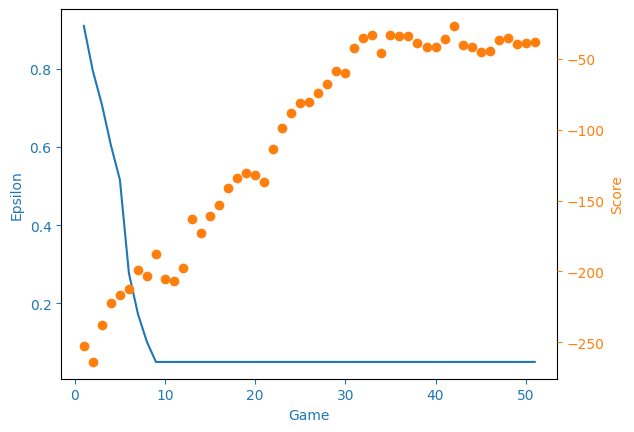

In [10]:
x = [i + 1 for i in range(51)]
plotLearning(x, scores, eps_history)